In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# __Section A - Coding__

In this section, we implement Decision Tree and Random Forest models from scratch for both classification and regression.

**Node Class** - this class represents a single node in the tree.   It stores the node impurity, the prediction, the split rule, and links to the child nodes.  
The same class is used for both classification and regression trees.

In [50]:
# Class for one node in a tree
class Node:
    def __init__(
        self,
        impurity=None,
        num_samples=None,
        prediction=None,
        num_samples_per_class=None,
        feature_index=None,
        threshold=None,
        left=None,
        right=None
    ):
        # impurity at this node
        self.impurity = impurity

        # number of samples in this node
        self.num_samples = num_samples

        # stored prediction:
        self.prediction = prediction

        # class counts (used in classification if needed)
        self.num_samples_per_class = num_samples_per_class

        # split rule
        self.feature_index = feature_index
        self.threshold = threshold

        # children
        self.left = left
        self.right = right

    def is_leaf_node(self):
        return self.left is None and self.right is None

**Gini Impurity** - this function computes the impurity of a node in the classification tree.  
It measures how mixed the class labels are inside the node.  
Formula: **Gini = 1 - Σ(pᵢ²)**.

In [51]:
# Gini impurity calculation function
def calculate_gini(y):
    n = len(y)

    if n == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / n

    return 1.0 - np.sum(probabilities ** 2)

**SSR Calculation** - this function computes the impurity of a node in the regression tree.  
It measures how far the target values are from their mean inside the node.  
Formula: **SSR = Σ(yᵢ - ȳ)²**.

In [52]:
# SSR calculation
def calculate_ssr(y):
    n = len(y)

    if n == 0:
        return 0.0

    mean_value = np.mean(y)
    ssr = np.sum((y - mean_value) ** 2)

    return ssr

**Best Split** - this function searches for the best feature and threshold to split the node.  
It supports both classification and regression, and can also use a random subset of features for random forest.

In [53]:
# find the best split for classification or regression
def find_best_split(X, y, feature_names, min_samples_leaf=5, is_classifier=True, candidate_features=None):
    n_samples, n_features = X.shape

    # too few samples
    if n_samples <= 1:
        return None, None, 0.0

    # compute parent impurity
    if is_classifier:
        parent_score = calculate_gini(y)
    else:
        parent_score = calculate_ssr(y)

    best_gain = 0.0
    best_feature_index = None
    best_threshold = None

    # use all features if no subset was given
    if candidate_features is None:
        candidate_features = list(range(n_features))

    # sort features alphabetically 
    sorted_feature_indices = sorted(candidate_features, key=lambda i: feature_names[i])

    for feature_index in sorted_feature_indices:
        values = X[:, feature_index]
        unique_values = np.unique(values)

        # no split possible
        if len(unique_values) < 2:
            continue

        # candidate thresholds
        thresholds = (unique_values[:-1] + unique_values[1:]) / 2

        for threshold in thresholds:
            left_mask = values <= threshold
            right_mask = values > threshold

            # skip invalid splits
            if left_mask.sum() < min_samples_leaf or right_mask.sum() < min_samples_leaf:
                continue

            left_y = y[left_mask]
            right_y = y[right_mask]

            # compute child impurity
            if is_classifier:
                left_score = calculate_gini(left_y)
                right_score = calculate_gini(right_y)

                child_score = (
                    (len(left_y) / n_samples) * left_score +
                    (len(right_y) / n_samples) * right_score
                )
            else:
                left_score = calculate_ssr(left_y)
                right_score = calculate_ssr(right_y)

                child_score = left_score + right_score

            gain = parent_score - child_score

            #keeps the first alphabetical feature
            if gain > best_gain:
                best_gain = gain
                best_feature_index = feature_index
                best_threshold = threshold

    return best_feature_index, best_threshold, best_gain

### __Decision Tree__

**Decision Tree Classifier** - this class implements a classification tree using Gini impurity.  
It predicts the majority class in each node.

In [54]:
class MyDecisionTreeClassifier:
    def __init__(self, min_samples_leaf=5, max_depth=None, max_features=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_names = None

    # train the model: prepare the input data, save the feature names, and start building the tree
    def fit(self, X, y, feature_names=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist() if feature_names is None else feature_names
            X = X.values
        else:
            n_features = X.shape[1]
            name_width = len(str(n_features - 1))
            self.feature_names = feature_names if feature_names is not None else [
               f"feat_{i:0{name_width}d}" for i in range(n_features)
            ]

        # convert y when needed
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        self.root = self._build_tree(X, y, depth=0)
        return self

    # predict the class for each sample in X
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        return np.array([self._traverse_tree(x, self.root) for x in X])

    # recursively build the tree
    def _build_tree(self, X, y, depth):
        num_samples = X.shape[0]

        # compute impurity and predicted class
        impurity = calculate_gini(y)
        values, counts = np.unique(y, return_counts=True)
        prediction = values[np.argmax(counts)] if len(y) > 0 else None
        num_samples_per_class = counts

        # stop conditions
        if (
            (self.max_depth is not None and depth >= self.max_depth)
            or num_samples < 2 * self.min_samples_leaf
            or impurity == 0.0
        ):
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=num_samples_per_class
            )

        # choose candidate features
        n_features = X.shape[1]
        if self.max_features is None:
            candidate_features = None
        else:
            n_selected = min(self.max_features, n_features)
            candidate_features = np.random.choice(n_features, size=n_selected, replace=False)

        # find the best split
        best_feat, best_thresh, best_gain = find_best_split(
            X,
            y,
            self.feature_names,
            self.min_samples_leaf,
            is_classifier=True,
            candidate_features=candidate_features
        )

        # return a leaf if no valid split was found
        if best_feat is None or best_gain <= 0.0:
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=num_samples_per_class
            )

        # split the data
        left_mask = X[:, best_feat] <= best_thresh
        right_mask = X[:, best_feat] > best_thresh

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(
            impurity=impurity,
            num_samples=num_samples,
            prediction=prediction,
            num_samples_per_class=num_samples_per_class,
            feature_index=best_feat,
            threshold=best_thresh,
            left=left_child,
            right=right_child
        )

    # follow the tree until reaching a leaf
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.prediction

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


**Decision Tree Regressor** - this class implements a regression tree using SSR reduction.  
It predicts the mean target value in each node.

In [55]:
class MyDecisionTreeRegressor:
    def __init__(self, min_samples_leaf=5, max_depth=None, max_features=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None
        self.feature_names = None

    # train the model: prepare the input data, save the feature names, and start building the tree
    def fit(self, X, y, feature_names=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist() if feature_names is None else feature_names
            X = X.values
        else:
            n_features = X.shape[1]
            name_width = len(str(n_features - 1))
            self.feature_names = feature_names if feature_names is not None else [
               f"feat_{i:0{name_width}d}" for i in range(n_features)
            ]           

        # convert y when needed
        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        self.root = self._build_tree(X, y, depth=0)
        return self

    # predict the target value for each sample in X
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        return np.array([self._traverse_tree(x, self.root) for x in X])

    # recursively build the tree
    def _build_tree(self, X, y, depth):
        num_samples = X.shape[0]

        # compute impurity and predicted value
        impurity = calculate_ssr(y)
        prediction = np.mean(y) if len(y) > 0 else None

        # stop conditions
        if (
            (self.max_depth is not None and depth >= self.max_depth)
            or num_samples < 2 * self.min_samples_leaf
            or impurity == 0.0
        ):
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=None
            )

        # choose candidate features
        n_features = X.shape[1]
        if self.max_features is None:
            candidate_features = None
        else:
            n_selected = min(self.max_features, n_features)
            candidate_features = np.random.choice(n_features, size=n_selected, replace=False)

        # find the best split
        best_feat, best_thresh, best_gain = find_best_split(
            X,
            y,
            self.feature_names,
            self.min_samples_leaf,
            is_classifier=False,
            candidate_features=candidate_features
        )

        # return a leaf if no valid split was found
        if best_feat is None or best_gain <= 0.0:
            return Node(
                impurity=impurity,
                num_samples=num_samples,
                prediction=prediction,
                num_samples_per_class=None
            )

        # split the data
        left_mask = X[:, best_feat] <= best_thresh
        right_mask = X[:, best_feat] > best_thresh

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(
            impurity=impurity,
            num_samples=num_samples,
            prediction=prediction,
            num_samples_per_class=None,
            feature_index=best_feat,
            threshold=best_thresh,
            left=left_child,
            right=right_child
        )

    # follow the tree until reaching a leaf
    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.prediction

        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


### __Random Forest__

**Random Forest Helper Functions** - these functions support the random forest models.  
They create bootstrap samples and combine predictions from multiple trees.

In [56]:
# create a bootstrap sample
def bootstrap_sample(X, y):
    n_samples = X.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)

    X_sample = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
    y_sample = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

    return X_sample, y_sample


# return the most common class
def majority_vote(predictions):
    values, counts = np.unique(predictions, return_counts=True)
    return values[np.argmax(counts)]


# return the average prediction
def average_predictions(predictions):
    return np.mean(predictions)

**Random Forest Classifier** - this class implements a random forest for classification.  
It trains multiple decision trees on bootstrap samples and combines their predictions by majority voting.

In [57]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=10, min_samples_leaf=5, max_depth=None, max_features=None):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    # train the model: create bootstrap samples and train multiple trees
    def fit(self, X, y):
        self.trees = []

        n_features = X.shape[1]
        max_features = self.max_features if self.max_features is not None else max(1, int(np.sqrt(n_features)))

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = MyDecisionTreeClassifier(
                min_samples_leaf=self.min_samples_leaf,
                max_depth=self.max_depth,
                max_features=max_features
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    # predict the class for each sample in X
    def predict(self, X):
        all_predictions = []

        for tree in self.trees:
            all_predictions.append(tree.predict(X))

        all_predictions = np.array(all_predictions)

        final_predictions = [
            majority_vote(all_predictions[:, i])
            for i in range(all_predictions.shape[1])
        ]

        return np.array(final_predictions)

    # compute classification accuracy
    def score(self, X, y):
        y_pred = self.predict(X)

        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        return np.mean(y_pred == y)


**Random Forest Regressor** - this class implements a random forest for regression.  
It trains multiple regression trees on bootstrap samples and combines their predictions by averaging.

In [58]:
class MyRandomForestRegressor:
    def __init__(self, n_estimators=10, min_samples_leaf=5, max_depth=None, max_features=None):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    # train the model: create bootstrap samples and train multiple trees
    def fit(self, X, y):
        self.trees = []

        n_features = X.shape[1]
        max_features = self.max_features if self.max_features is not None else max(1, n_features // 3)

        for _ in range(self.n_estimators):
            X_sample, y_sample = bootstrap_sample(X, y)

            tree = MyDecisionTreeRegressor(
                min_samples_leaf=self.min_samples_leaf,
                max_depth=self.max_depth,
                max_features=max_features
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    # predict the target value for each sample in X
    def predict(self, X):
        all_predictions = []

        for tree in self.trees:
            all_predictions.append(tree.predict(X))

        all_predictions = np.array(all_predictions)

        final_predictions = [
            average_predictions(all_predictions[:, i])
            for i in range(all_predictions.shape[1])
        ]

        return np.array(final_predictions)

    # compute regression mse
    def score(self, X, y):
        y_pred = self.predict(X)

        if isinstance(y, pd.Series):
            y = y.values
        else:
            y = np.array(y)

        return np.mean((y - y_pred) ** 2)

# __Section B - Data Preparation__
**Data visualization** - in this part, we explore the distributions of the target and key variables.  
The selected plots help us inspect outliers, artifacts, and the relationship between vehicle condition and price.

visualization setup- import the data from the csv file, define colors and style

In [ ]:
# load the dataset
df = pd.read_csv("vehicle_price_prediction.csv")

# plotting style
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 8


print("dataset shape:", df.shape)
display(df.head())

df.info()

 - **price distribution** -we chose a histogram because price is the main regression target.
It helps us see the overall spread, skewness, and whether many vehicles are concentrated in lower price ranges.

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["price"], bins=50, edgecolor="black", label="Vehicle Prices")
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.xlim(left=0)
plt.legend()
plt.show()

**correlation heatmap of numerical features** -  we chose a heatmap to summarize the relationships between the main numerical variables in the dataset.
Using a diverging color scale makes it easier to distinguish positive and negative correlations and identify the features most strongly related to price.

In [ ]:
selected_numeric = [
    "year",
    "mileage",
    "engine_hp",
    "owner_count",
    "vehicle_age",
    "mileage_per_year",
    "brand_popularity",
    "price"
]

plt.figure(figsize=(10, 8))
corr_matrix = df[selected_numeric].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**vehicle characteristics across price groups** - we grouped price into ranges and plotted the median values of mileage, engine_hp, and vehicle_age for each group.
We used the median rather than the mean because it is less affected by extreme values, making the trends more representative of a typical vehicle in each price range.

In [ ]:
price_bins = [0, 5000, 10000, 15000, 20000, 30000, 50000, float("inf")]
price_labels = ["0–5K", "5K–10K", "10K–15K", "15K–20K", "20K–30K", "30K–50K", "50K+"]

df["price_group"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_summary = (
    df.groupby("price_group", observed=False)[["mileage", "engine_hp", "vehicle_age"]]
    .median()
    .reset_index()
)

set2_colors = sns.color_palette("Set2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="mileage",
    marker="o",
    color=set2_colors[0],
    linewidth=2.2,
    markersize=7,
    ax=axes[0]
)
axes[0].set_title("Median Mileage by Price Group", fontsize=11)
axes[0].set_xlabel("Price Group", fontsize=10)
axes[0].set_ylabel("Median Mileage", fontsize=10)
axes[0].tick_params(axis="x", labelsize=8, rotation=25)
axes[0].tick_params(axis="y", labelsize=9)
axes[0].set_ylim(bottom=0)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="engine_hp",
    marker="o",
    color=set2_colors[1],
    linewidth=2.2,
    markersize=7,
    ax=axes[1]
)
axes[1].set_title("Median Engine HP by Price Group", fontsize=11)
axes[1].set_xlabel("Price Group", fontsize=10)
axes[1].set_ylabel("Median Engine HP", fontsize=10)
axes[1].tick_params(axis="x", labelsize=8, rotation=25)
axes[1].tick_params(axis="y", labelsize=9)
axes[1].set_ylim(bottom=0)

sns.lineplot(
    data=price_summary,
    x="price_group",
    y="vehicle_age",
    marker="o",
    color=set2_colors[2],
    linewidth=2.2,
    markersize=7,
    ax=axes[2]
)
axes[2].set_title("Median Vehicle Age by Price Group", fontsize=11)
axes[2].set_xlabel("Price Group", fontsize=10)
axes[2].set_ylabel("Median Vehicle Age", fontsize=10)
axes[2].tick_params(axis="x", labelsize=8, rotation=25)
axes[2].tick_params(axis="y", labelsize=9)
axes[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In the data preparation stage, we checked for missing values in all features. 
We found that missing values appeared only in the `accident_history` feature, while all other features were complete.

Since this feature is categorical and contains a large number of missing values, we chose not to remove the rows in order to avoid losing a significant portion of the dataset. 
Instead, we replaced the missing values with the category "Unknown", allowing the model to treat missing information as a separate category.

After this step, we verified that no missing values remained in the dataset.


In [5]:
# Data Preparation - Missing Values

# Check missing values in each column
missing_values = df.isnull().sum()
print("Missing values before handling:")
print(missing_values)

# Handle missing values in accident_history
# Since this is a categorical feature with many missing values,
# we replace missing values with 'Unknown' instead of dropping rows.
df['accident_history'] = df['accident_history'].fillna('Unknown')

# Verify that missing values were handled
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64

Missing values after handling:
make                0
model               0
year                0
mileage             0
engine_hp           0
transmission        0
fuel_type           0
drivetrain          0
body_type           0
exterior_color      0
interior_color      0
owner_count         0
accident_history    0
seller_type         0
condition           0
trim                0
vehicle_age         0
mileage_p

Outlier Analysis 

In [6]:
# Outlier Analysis - Price (IQR)

Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

price_outliers = df[(df['price'] < lower_bound_price) | (df['price'] > upper_bound_price)]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 25524


For the price feature, the IQR method identified several outliers. 
These values represent vehicles with unusually high or low prices compared to the majority of the data. 
Such outliers are expected in this dataset, as vehicle prices can vary significantly depending on factors such as brand, model, and condition. 
Therefore, these values likely reflect real-world variation rather than data errors.

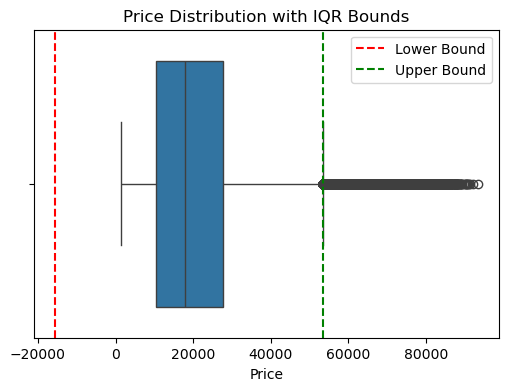

In [12]:
# Boxplot with IQR bounds for Price

plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])

plt.axvline(lower_bound_price, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound_price, color='green', linestyle='--', label='Upper Bound')

plt.title("Price Distribution with IQR Bounds")
plt.xlabel("Price")
plt.legend()

plt.show()

In [10]:
# Outlier Analysis - Mileage using IQR

# Calculate Q1, Q3 and IQR
Q1_mileage = df['mileage'].quantile(0.25)
Q3_mileage = df['mileage'].quantile(0.75)
IQR_mileage = Q3_mileage - Q1_mileage

# Calculate bounds
lower_bound_mileage = Q1_mileage - 1.5 * IQR_mileage
upper_bound_mileage = Q3_mileage + 1.5 * IQR_mileage

# Find outliers
mileage_outliers = df[(df['mileage'] < lower_bound_mileage) | 
                      (df['mileage'] > upper_bound_mileage)]

# Print results
print("Mileage Statistics:")
print(df['mileage'].describe())

print("\nIQR Calculation:")
print("Q1:", Q1_mileage)
print("Q3:", Q3_mileage)
print("IQR:", IQR_mileage)

print("\nBounds:")
print("Lower bound:", lower_bound_mileage)
print("Upper bound:", upper_bound_mileage)

print("\nNumber of outliers:", len(mileage_outliers))

Mileage Statistics:
count    1000000.000000
mean      112660.126464
std        72088.236925
min          500.000000
25%        57654.000000
50%       103331.000000
75%       157865.000000
max       300000.000000
Name: mileage, dtype: float64

IQR Calculation:
Q1: 57654.0
Q3: 157865.0
IQR: 100211.0

Bounds:
Lower bound: -92662.5
Upper bound: 308181.5

Number of outliers: 0


For the mileage feature, no outliers were detected using the IQR method. 
Although high mileage values (e.g., around 300,000 km) exist, they are not considered outliers because they appear frequently in the dataset. 
This suggests that these values are part of the natural distribution or may reflect repeated patterns in the data, rather than true anomalies.

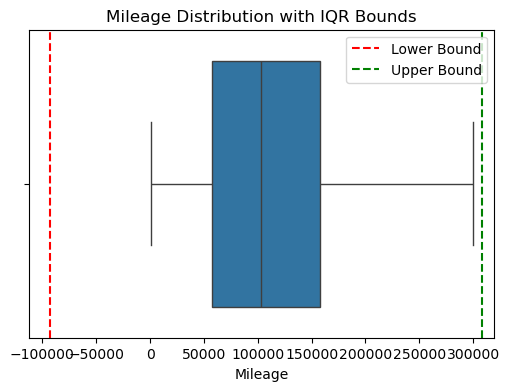

In [13]:
# Boxplot with IQR bounds for Mileage

plt.figure(figsize=(6,4))
sns.boxplot(x=df['mileage'])

plt.axvline(lower_bound_mileage, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound_mileage, color='green', linestyle='--', label='Upper Bound')

plt.title("Mileage Distribution with IQR Bounds")
plt.xlabel("Mileage")
plt.legend()

plt.show()